### Make Circles

In [11]:
import torch
import matplotlib.pyplot as plt
from torch import nn
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# 1. Data
n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

device = "cuda" if torch.cuda.is_available() else "cpu"

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

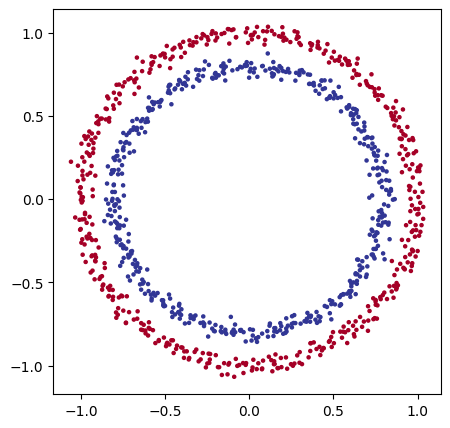

In [12]:
plt.figure(figsize=(5,5))

plt.scatter(X[:,0], X[:,1], c=y, s=5, cmap=plt.cm.RdYlBu)
plt.show()

In [13]:
# 2. Accuracy function
def accuracy_fn(y_pred, y_true):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100


# 3. Model
model = nn.Sequential(
    nn.Linear(2, 16), 
    nn.ReLU(), 
    nn.Linear(16, 16), 
    nn.ReLU(), 
    nn.Linear(16, 1)
).to(device)

# 4. Loss & optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 5. Training loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100
for epoch in range(epochs):
    model.train()
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(test_pred, y_test)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch} | Loss {loss:.4f}, Acc {acc:.2f}% | Test {test_loss:.4f}, Test Acc {test_acc:.2f}%"
        )

Epoch 0 | Loss 0.7096, Acc 50.00% | Test 0.6969, Test Acc 50.00%
Epoch 10 | Loss 0.6822, Acc 62.38% | Test 0.6852, Test Acc 60.50%
Epoch 20 | Loss 0.6590, Acc 61.62% | Test 0.6686, Test Acc 56.50%
Epoch 30 | Loss 0.6102, Acc 67.12% | Test 0.6296, Test Acc 63.00%
Epoch 40 | Loss 0.5099, Acc 88.88% | Test 0.5350, Test Acc 84.50%
Epoch 50 | Loss 0.3470, Acc 99.12% | Test 0.3752, Test Acc 99.00%
Epoch 60 | Loss 0.1863, Acc 99.62% | Test 0.2251, Test Acc 100.00%
Epoch 70 | Loss 0.0864, Acc 100.00% | Test 0.1192, Test Acc 99.50%
Epoch 80 | Loss 0.0414, Acc 100.00% | Test 0.0640, Test Acc 100.00%
Epoch 90 | Loss 0.0243, Acc 100.00% | Test 0.0427, Test Acc 100.00%


In [14]:
# Saving trained model

from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "binary_classification_circle_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
print(f"Saving to: {MODEL_SAVE_PATH}")
torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

Saving to: models\binary_classification_circle_model.pth


In [15]:
loaded_model = nn.Sequential(
    nn.Linear(2, 16), 
    nn.ReLU(), 
    nn.Linear(16, 16), 
    nn.ReLU(), 
    nn.Linear(16, 1)
).to(device)

loaded_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

model.eval()
with torch.inference_mode():
    y_preds = model(X_test)

loaded_model.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model(X_test)

torch.eq(y_preds, loaded_model_preds).sum()    

tensor(200)